# 10b — GDP as a Spatial Proxy for Adaptive Capacity

Adapts notebook 10 to use the **Kummu et al. (2018) global 1 km GDP raster** (2019 vintage)
in place of the Salvador-specific Brazilian Census income layer.

**Why GDP instead of income?**  
The census income GeoJSON in notebook 10 is Salvador-only and requires a separate download.
The global GDP raster covers all three Brazilian cities (Salvador, Teresina, Cáceres)
with a consistent methodology, enabling cross-city comparison.

**What this notebook does:**
1. Extracts a small city-level GeoTIFF for each city from the 2.2 GB global raster (cached).
2. Computes mean GDP per neighbourhood via zonal statistics.
3. Compares GDP spatial patterns with heat exposure and population across all three cities.
4. Optionally compares GDP ranks with census income ranks for Salvador (if income GeoJSON present).
5. Produces GDP-weighted person-day indices following the same methodology as notebook 10.

**Important caveat:**  
GDP (USD PPP/km² or per capita) and household income (BRL/month) are
**incommensurable quantities** — they cannot be directly compared numerically.
The comparison in this notebook is limited to **rank-order patterns** across the
22 Salvador neighbourhoods, not absolute values.

**GDP data:** `2019GDP.tif` — Kummu et al. global 1 km GDP raster, 2019.  
CRS: ESRI:54009 (World Mollweide, equal-area).  Resolution: 1 000 m.

**Prerequisites:** `01_data_acquisition`, `02_compute_baselines`, `07_person_days_diagnostic`.

## Setup

In [14]:
import os, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import geopandas as gpd
import xarray as xr
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.windows import from_bounds as window_from_bounds
from pyproj import Transformer
from shapely.geometry import mapping
from scipy.stats import spearmanr

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from utils.heat import (
    CITIES,
    load_city, load_tx90p_threshold, load_neighbourhood_boundaries,
    compute_absolute_heat_days, compute_person_days_map,
    aggregate_to_neighbourhoods, aggregate_person_days_to_neighbourhoods,
)

# ---- Configuration ----------------------------------------------------------
DATA_DIR      = 'data'
GDP_TIF       = '/Users/martynclark/Downloads/updated real GDP/2019/2019GDP.tif'
GDP_CRS       = 'ESRI:54009'   # World Mollweide — native CRS of the GDP raster
BUFFER_M      = 5_000          # 5 km buffer around city bbox when extracting window
DIAG_YEAR     = 2020
ABS_THRESHOLD = 30.0
PERCENTILE    = 90
CITY_KEYS     = ['salvador', 'teresina', 'caceres']

# Metric UTM CRS per city (for centroid/area computations — not used for GDP)
CITY_PROJ_CRS = {
    'salvador':  'EPSG:31984',   # SIRGAS 2000 / UTM zone 24S
    'teresina':  'EPSG:31983',   # SIRGAS 2000 / UTM zone 23S
    'caceres':   'EPSG:31981',   # SIRGAS 2000 / UTM zone 21S
}

table_styles = [
    {'selector': 'caption', 'props': 'font-size:1em; font-weight:bold; padding-bottom:8px;'},
    {'selector': 'th',      'props': 'text-align:center; white-space:nowrap; font-size:0.85em;'},
    {'selector': 'td',      'props': 'text-align:center; font-size:0.85em;'},
]

def load_pop_grid(city, year):
    return xr.open_dataset(f'{DATA_DIR}/{city}_pop_1km_{year}.nc')['population']

def count_doy_exceedances(da, thresh_doy):
    aligned = thresh_doy.sel(dayofyear=da.time.dt.dayofyear)
    return (da > aligned).resample(time='YS').sum(dim='time')

## Step 1 — Extract city GDP windows from the global raster

The global GDP raster is 2.2 GB (15 517 × 36 080 pixels).  Loading the whole file
into memory is unnecessary: each city's bounding box covers only ~50–80 pixels per
side.  This cell:

1. Reprojects each city's WGS84 bounding box to ESRI:54009 (Mollweide).
2. Uses `rasterio.windows.from_bounds` to define the exact pixel window — the file is
   internally tiled (128 × 128 blocks), so only the relevant tiles are read from disk.
3. Saves the extracted window as a small GeoTIFF in `data/gdp_2019_{city}.tif`.

On subsequent runs the cached files are loaded directly; the large source file is not
opened at all.

In [15]:
def extract_city_gdp(city_key, data_dir=DATA_DIR, gdp_tif=GDP_TIF, buffer_m=BUFFER_M):
    """Extract GDP window for a city bbox and cache as a small GeoTIFF in ESRI:54009."""
    out_path = Path(data_dir) / f'gdp_2019_{city_key}.tif'
    if out_path.exists():
        sz_kb = out_path.stat().st_size / 1024
        print(f'  {city_key}: cache found — {out_path.name} ({sz_kb:.0f} KB)')
        return out_path

    cfg  = CITIES[city_key]
    bbox = cfg['bbox']

    # Reproject WGS84 bbox corners to Mollweide
    t = Transformer.from_crs('EPSG:4326', GDP_CRS, always_xy=True)
    xs, ys = t.transform(
        [bbox['west'], bbox['east']],
        [bbox['south'], bbox['north']],
    )
    west_m  = min(xs) - buffer_m
    east_m  = max(xs) + buffer_m
    south_m = min(ys) - buffer_m
    north_m = max(ys) + buffer_m

    with rasterio.open(gdp_tif) as src:
        win = window_from_bounds(west_m, south_m, east_m, north_m, src.transform)
        win = win.round_offsets().round_lengths()
        arr          = src.read(1, window=win)
        win_transform = src.window_transform(win)

        profile = src.profile.copy()
        profile.update({
            'height':    int(win.height),
            'width':     int(win.width),
            'transform': win_transform,
            'compress':  'lzw',
            'tiled':     False,   # small file; no need for internal tiling
        })

        with rasterio.open(out_path, 'w', **profile) as dst:
            dst.write(arr, 1)

    sz_kb = out_path.stat().st_size / 1024
    print(f'  {city_key}: extracted {int(win.height)}×{int(win.width)} px '
          f'→ {out_path.name} ({sz_kb:.0f} KB)')
    return out_path


print(f'GDP source: {GDP_TIF}')
print('Extracting city windows (reads only relevant tiles from the 2.2 GB file):')
gdp_tif_paths = {}
for city in CITY_KEYS:
    gdp_tif_paths[city] = extract_city_gdp(city)

# Quick sanity check on values
print('\nGDP value ranges in extracted windows:')
for city, tif_path in gdp_tif_paths.items():
    with rasterio.open(tif_path) as src:
        arr    = src.read(1).astype(float)
        nodata = src.nodata
        arr[arr == nodata] = np.nan
        valid  = arr[np.isfinite(arr) & (arr > 0)]
    print(f'  {city:12s}  n_px={len(valid):4d}  '
          f'min={valid.min():.2f}  median={np.median(valid):.2f}  max={valid.max():.2f}')

GDP source: /Users/martynclark/Downloads/updated real GDP/2019/2019GDP.tif
Extracting city windows (reads only relevant tiles from the 2.2 GB file):
  salvador: cache found — gdp_2019_salvador.tif (6 KB)
  teresina: cache found — gdp_2019_teresina.tif (8 KB)
  caceres: cache found — gdp_2019_caceres.tif (3 KB)

GDP value ranges in extracted windows:
  salvador      n_px=1426  min=0.12  median=8.47  max=45.88
  teresina      n_px=6546  min=0.04  median=0.12  max=39.25
  caceres       n_px=7918  min=0.07  median=0.12  max=29.78


## Step 2 — Load neighbourhood boundaries

In [16]:
districts = {}
for city in CITY_KEYS:
    gdf = load_neighbourhood_boundaries(city, DATA_DIR)
    districts[city] = gdf
    print(f'  {city}: {len(gdf)} neighbourhoods, CRS={gdf.crs}')

Loaded 22 neighbourhoods from cache: data/geobr_salvador_neighbourhoods_2010.gpkg
  salvador: 22 neighbourhoods, CRS=EPSG:4326
Loaded 112 neighbourhoods from cache: data/geobr_teresina_neighbourhoods_2010.gpkg
  teresina: 112 neighbourhoods, CRS=EPSG:4326
Loaded 43 neighbourhoods from cache: data/geobr_caceres_neighbourhoods_2010.gpkg
  caceres: 43 neighbourhoods, CRS=EPSG:4326


## Step 3 — Zonal statistics: mean GDP per neighbourhood

Each neighbourhood polygon is reprojected to ESRI:54009 (the native Mollweide CRS of the
GDP raster) before masking.  Using the equal-area projection for the mask operation
ensures that pixels at different latitudes are treated equally — this matters for an
equal-area raster like this one.

`rasterio.mask.mask` clips the raster to each polygon in turn; only the pixels whose
centres fall inside the polygon contribute to the mean.  No rasterstats dependency needed.

In [17]:
def gdp_zonal_stats(gdf_4326, gdp_tif_path):
    """Mean GDP per neighbourhood.  Returns DataFrame: name, mean_gdp, n_gdp_px.

    all_touched=True ensures that small neighbourhoods (<1 km²) which contain no
    pixel centre still receive the value of any pixel they touch.  At 1 km resolution
    many urban neighbourhoods are smaller than one pixel, so this is necessary for
    full coverage.
    """
    with rasterio.open(gdp_tif_path) as src:
        raster_crs = src.crs.to_string()
        nodata     = src.nodata

    gdf_proj = gdf_4326.to_crs(raster_crs)
    rows = []

    with rasterio.open(gdp_tif_path) as src:
        for _, row in gdf_proj.iterrows():
            try:
                out_arr, _ = rio_mask(
                    src, [mapping(row.geometry)], crop=True,
                    nodata=nodata, all_touched=True,
                )
                vals = out_arr[0].astype(float)
                if nodata is not None:
                    vals[np.isclose(vals, nodata)] = np.nan
                valid    = vals[np.isfinite(vals) & (vals > 0)]
                mean_val = float(valid.mean()) if len(valid) > 0 else np.nan
                n_px     = int(len(valid))
            except Exception:
                mean_val, n_px = np.nan, 0
            rows.append({'name': row['name'], 'mean_gdp': mean_val, 'n_gdp_px': n_px})

    return pd.DataFrame(rows)


print('Computing GDP zonal statistics per neighbourhood:')
gdp_by_nbhd = {}
for city in CITY_KEYS:
    df = gdp_zonal_stats(districts[city], gdp_tif_paths[city])
    n_missing = df['mean_gdp'].isna().sum()
    gdp_by_nbhd[city] = df
    print(f'  {city}: {len(df)} neighbourhoods, '
          f'{n_missing} missing, '
          f'mean GDP={df["mean_gdp"].mean():.2f}')

print('\nGDP units: assumed USD PPP/km² or similar — verify from source documentation.')
print('Note: all_touched=True used to capture neighbourhoods smaller than 1 pixel.')

Computing GDP zonal statistics per neighbourhood:
  salvador: 22 neighbourhoods, 0 missing, mean GDP=29.93
  teresina: 112 neighbourhoods, 0 missing, mean GDP=28.78
  caceres: 43 neighbourhoods, 0 missing, mean GDP=19.02

GDP units: assumed USD PPP/km² or similar — verify from source documentation.
Note: all_touched=True used to capture neighbourhoods smaller than 1 pixel.


## Step 4 — Load heat and population metrics for all three cities

In [18]:
def build_heat_pop_table(city_key, diag_year=DIAG_YEAR, abs_threshold=ABS_THRESHOLD,
                         percentile=PERCENTILE, data_dir=DATA_DIR):
    da     = load_city(city_key, data_dir)
    da.attrs['units'] = 'degC'
    thresh = load_tx90p_threshold(city_key, data_dir)
    pop    = load_pop_grid(city_key, diag_year)
    nbhd   = districts[city_key]

    abs_hd = compute_absolute_heat_days(da, diag_year, abs_threshold)

    tx_annual = count_doy_exceedances(da, thresh.sel(percentile=percentile))
    tx_hd = (
        tx_annual
        .isel(time=(tx_annual.time.dt.year == diag_year))
        .squeeze('time')
    )

    pop_nbhd    = aggregate_person_days_to_neighbourhoods(pop,    nbhd, col='population')
    abs_hd_nbhd = aggregate_to_neighbourhoods(abs_hd, nbhd, col='abs_hd')
    tx_hd_nbhd  = aggregate_to_neighbourhoods(tx_hd,  nbhd, col='tx90p_hd')
    abs_pd_nbhd = aggregate_person_days_to_neighbourhoods(
                      compute_person_days_map(abs_hd, pop), nbhd, col='abs_pd')
    tx_pd_nbhd  = aggregate_person_days_to_neighbourhoods(
                      compute_person_days_map(tx_hd, pop),  nbhd, col='tx90p_pd')

    df = nbhd[['name']].copy()
    df['population'] = pop_nbhd['population'].values
    df['abs_hd']     = abs_hd_nbhd['abs_hd'].values
    df['tx90p_hd']   = tx_hd_nbhd['tx90p_hd'].values
    df['abs_pd']     = abs_pd_nbhd['abs_pd'].values
    df['tx90p_pd']   = tx_pd_nbhd['tx90p_pd'].values
    return df.dropna().reset_index(drop=True)


heat_pop = {}
for city in CITY_KEYS:
    print(f'--- {city} ---')
    heat_pop[city] = build_heat_pop_table(city)
    print(f'    {len(heat_pop[city])} neighbourhoods\n')

--- salvador ---
salvador: shape {'time': 6497, 'lat': 55, 'lon': 67}  2003-01-01 to 2020-12-30
salvador TX90p threshold: shape {'percentile': 2, 'lat': 55, 'lon': 67, 'dayofyear': 365}  window=5  percentiles=[90, 95]  range 26.0–73.7 °C
    22 neighbourhoods

--- teresina ---
teresina: shape {'time': 6497, 'lat': 67, 'lon': 78}  2003-01-01 to 2020-12-30
teresina TX90p threshold: shape {'percentile': 2, 'lat': 67, 'lon': 78, 'dayofyear': 365}  window=5  percentiles=[90, 95]  range 32.7–60.4 °C
    112 neighbourhoods

--- caceres ---
caceres: shape {'time': 6497, 'lat': 89, 'lon': 89}  2003-01-01 to 2020-12-30
caceres TX90p threshold: shape {'percentile': 2, 'lat': 89, 'lon': 89, 'dayofyear': 365}  window=5  percentiles=[90, 95]  range 30.9–43.9 °C
    43 neighbourhoods



## Step 5 — Merge GDP into city tables

In [19]:
city_df = {}
for city in CITY_KEYS:
    df = heat_pop[city].merge(gdp_by_nbhd[city][['name', 'mean_gdp', 'n_gdp_px']],
                              on='name', how='left')
    n_missing = df['mean_gdp'].isna().sum()
    if n_missing:
        print(f'WARNING {city}: {n_missing} neighbourhood(s) with no GDP data')
    df = df.dropna(subset=['mean_gdp']).reset_index(drop=True)

    for col in ['population', 'abs_hd', 'tx90p_hd', 'abs_pd', 'tx90p_pd', 'mean_gdp']:
        df[f'rank_{col}'] = df[col].rank(ascending=False, method='min').astype(int)

    city_df[city] = df
    print(f'{city}: {len(df)} neighbourhoods merged')

# Preview Salvador
display(city_df['salvador'][['name', 'population', 'tx90p_hd', 'tx90p_pd', 'mean_gdp', 'n_gdp_px']]
    .sort_values('mean_gdp', ascending=False)
    .style
    .format({'population': '{:,.0f}', 'tx90p_hd': '{:.1f}',
             'tx90p_pd': '{:,.0f}', 'mean_gdp': '{:.2f}', 'n_gdp_px': '{:.0f}'})
    .background_gradient(subset=['mean_gdp'], cmap='RdYlGn')
    .set_caption(f'Salvador — heat, population, GDP ({DIAG_YEAR} heat/pop; 2019 GDP)')
    .set_table_styles(table_styles))

salvador: 22 neighbourhoods merged
teresina: 112 neighbourhoods merged
caceres: 43 neighbourhoods merged


,name,population,tx90p_hd,tx90p_pd,mean_gdp,n_gdp_px
12,Passo,"6,502",0.0,0,34.76,1
15,Pilar,925,0.0,0,33.95,2
10,Nazaré,"10,163",3.0,"30,490",32.82,3
6,São Caetano,"395,082",11.2,"4,303,580",32.82,41
1,Brotas,"177,034",11.7,"2,078,214",32.33,19
5,Santo Antônio,"195,988",7.0,"1,562,627",32.28,12
0,Amaralina,"270,322",10.7,"2,845,064",32.17,13
4,Pirajá,"371,435",10.9,"4,006,178",32.15,60
13,Penha,"137,448",2.1,"445,397",31.76,7
17,Santana,"19,484",3.0,"58,452",31.73,4


## Step 6 — GDP spatial pattern: choropleth maps (all three cities)

Each panel shows mean GDP per neighbourhood, classified by quintile.  Cities cannot be
directly compared because their neighbourhood counts and administrative geographies differ.

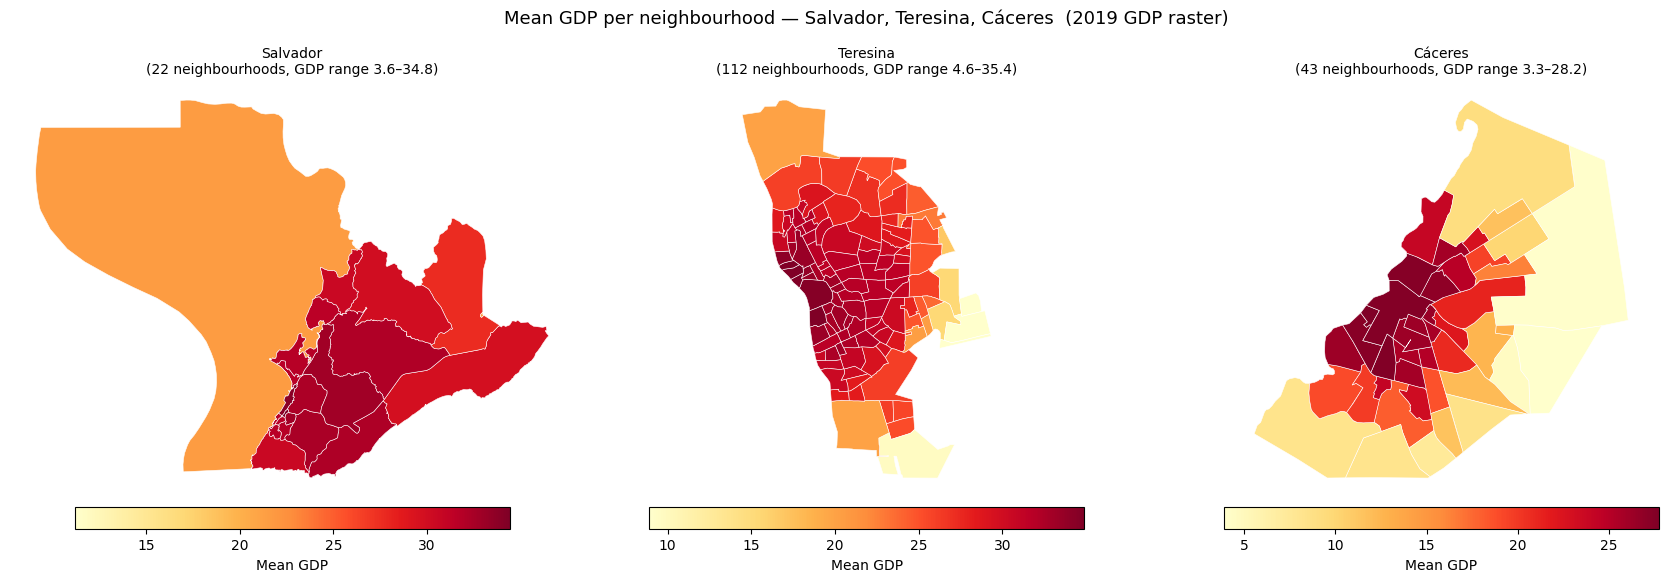

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    f'Mean GDP per neighbourhood — Salvador, Teresina, Cáceres  (2019 GDP raster)',
    fontsize=13,
)

CITY_LABELS = {
    'salvador': 'Salvador',
    'teresina': 'Teresina',
    'caceres':  'Cáceres',
}

for ax, city in zip(axes, CITY_KEYS):
    df     = city_df[city]
    gdf    = districts[city].merge(df[['name', 'mean_gdp']], on='name', how='left')
    vmin   = df['mean_gdp'].quantile(0.02)
    vmax   = df['mean_gdp'].quantile(0.98)

    gdf.plot(
        column='mean_gdp', ax=ax, cmap='YlOrRd',
        vmin=vmin, vmax=vmax,
        edgecolor='white', linewidth=0.4,
        legend=True,
        legend_kwds={
            'label': 'Mean GDP', 'orientation': 'horizontal',
            'shrink': 0.7, 'pad': 0.02,
        },
        missing_kwds={'color': '#cccccc', 'label': 'No data'},
    )
    ax.set_title(
        f'{CITY_LABELS[city]}\n'
        f'({len(df)} neighbourhoods, GDP range {df["mean_gdp"].min():.1f}–{df["mean_gdp"].max():.1f})',
        fontsize=10,
    )
    ax.set_axis_off()

plt.tight_layout()
plt.show()

## Step 6b — Side-by-side: GDP vs TX90p heat days (all three cities)

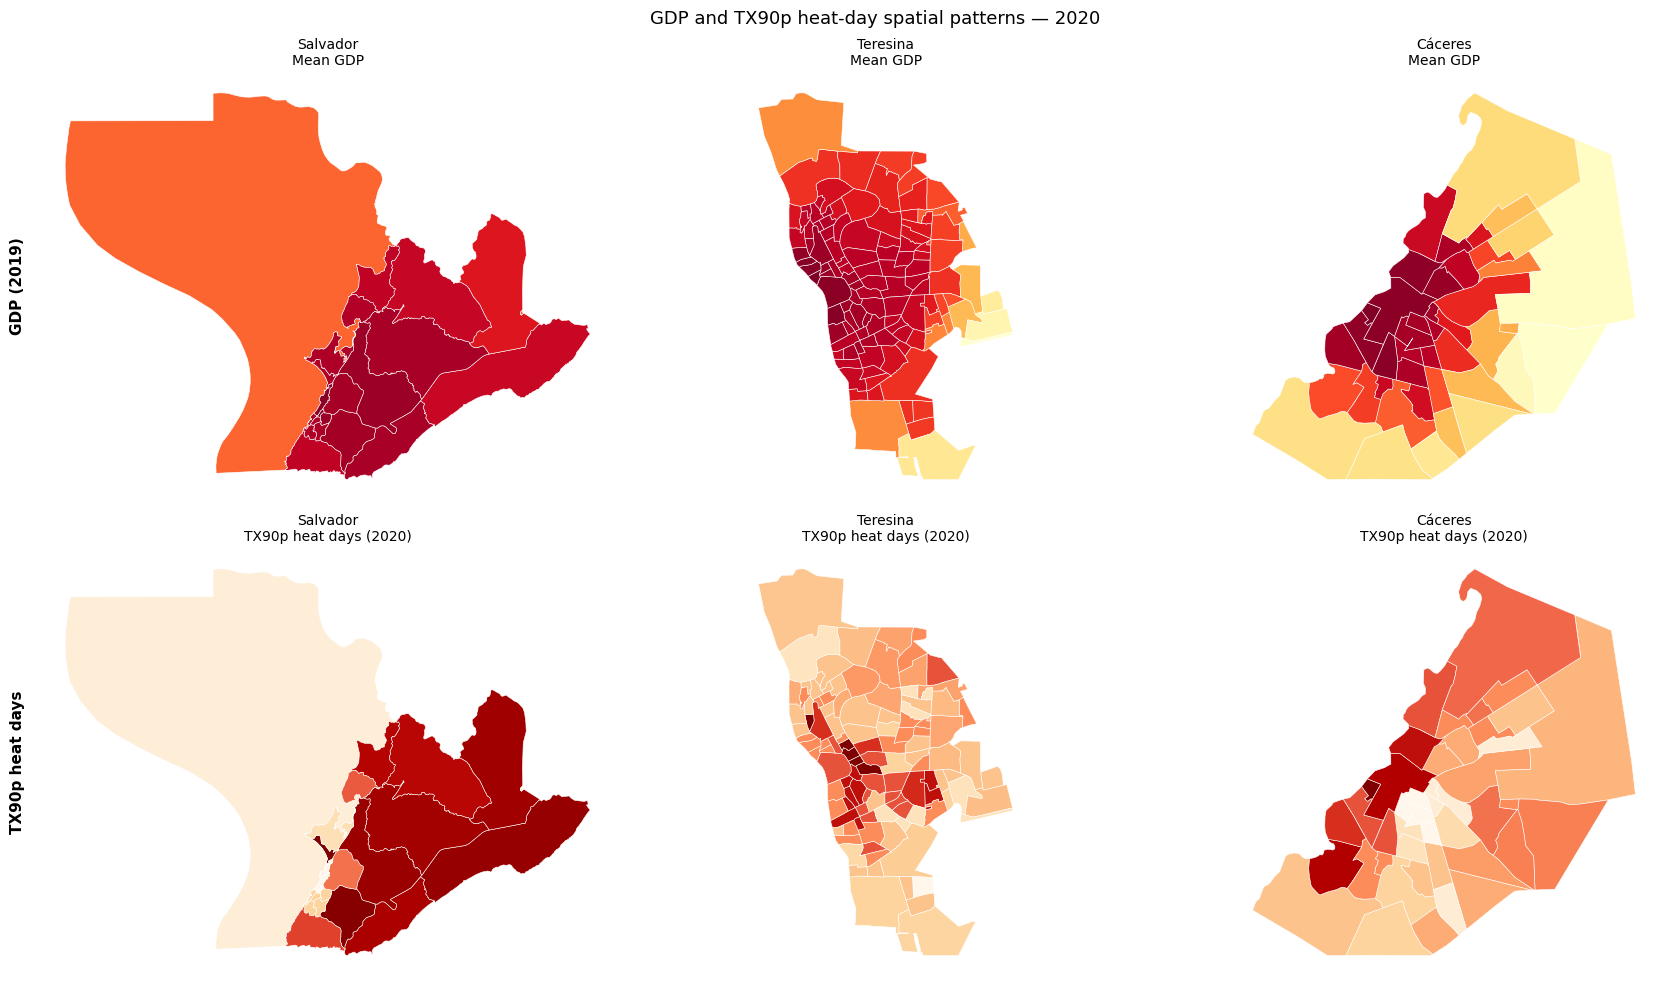

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    f'GDP and TX90p heat-day spatial patterns — {DIAG_YEAR}',
    fontsize=13,
)

for col_idx, city in enumerate(CITY_KEYS):
    df  = city_df[city]
    gdf = districts[city].merge(df[['name', 'mean_gdp', 'tx90p_hd']], on='name', how='left')

    # Row 0: GDP
    ax = axes[0, col_idx]
    gdf.plot(column='mean_gdp', ax=ax, cmap='YlOrRd',
             edgecolor='white', linewidth=0.4, legend=False,
             missing_kwds={'color': '#cccccc'})
    ax.set_title(f'{CITY_LABELS[city]}\nMean GDP', fontsize=10)
    ax.set_axis_off()

    # Row 1: TX90p heat days
    ax = axes[1, col_idx]
    gdf.plot(column='tx90p_hd', ax=ax, cmap='OrRd',
             edgecolor='white', linewidth=0.4, legend=False,
             missing_kwds={'color': '#cccccc'})
    ax.set_title(f'{CITY_LABELS[city]}\nTX90p heat days ({DIAG_YEAR})', fontsize=10)
    ax.set_axis_off()

axes[0, 0].annotate('GDP (2019)', xy=(-0.05, 0.5), xycoords='axes fraction',
                    rotation=90, va='center', fontsize=11, fontweight='bold')
axes[1, 0].annotate('TX90p heat days', xy=(-0.05, 0.5), xycoords='axes fraction',
                    rotation=90, va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Step 7 — CV comparison: GDP vs heat days vs population

Coefficient of variation (std/mean) across neighbourhoods in each city.
A higher CV means greater spatial inequality in that variable.

CV (std/mean) across neighbourhoods — all three cities:


,Population,Abs heat days,TX90p heat days,Mean GDP
City,,,,
Salvador,1.041,0.441,0.642,0.215
Teresina,0.878,0.012,0.190,0.200
Cáceres,0.506,0.007,0.024,0.413


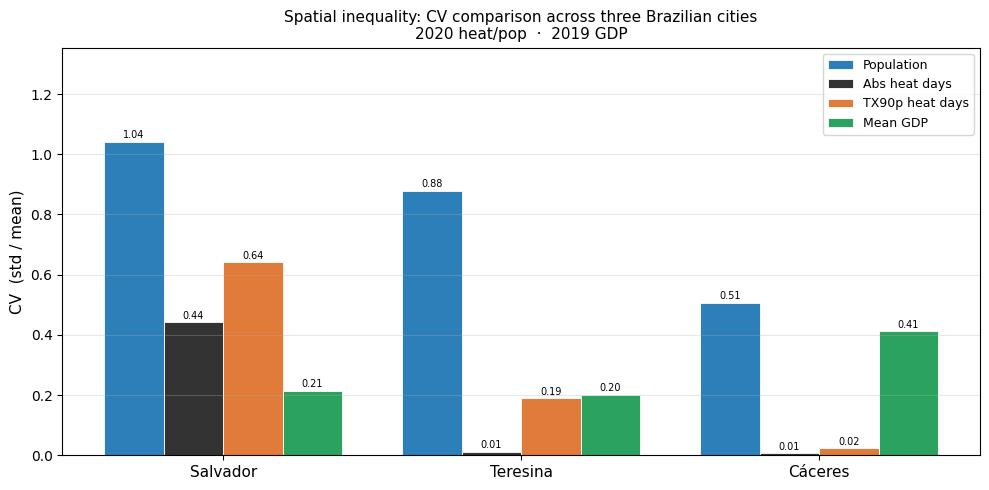

In [22]:
def cv(s):
    return s.std() / s.mean() if s.mean() != 0 else np.nan

cv_rows = []
for city in CITY_KEYS:
    df = city_df[city]
    cv_rows.append({
        'City':            CITY_LABELS[city],
        'Population':      cv(df['population']),
        'Abs heat days':   cv(df['abs_hd']),
        'TX90p heat days': cv(df['tx90p_hd']),
        'Mean GDP':        cv(df['mean_gdp']),
    })

cv_df = pd.DataFrame(cv_rows)
print('CV (std/mean) across neighbourhoods — all three cities:')
display(
    cv_df.set_index('City').style
    .format('{:.3f}')
    .background_gradient(cmap='YlOrRd', axis=None)
    .set_caption('Coefficient of variation — higher = greater spatial inequality')
    .set_table_styles(table_styles)
)

# Bar chart
cv_plot = cv_df.set_index('City')
x  = np.arange(len(CITY_KEYS))
w  = 0.2
cols_plot  = ['Population', 'Abs heat days', 'TX90p heat days', 'Mean GDP']
colors     = ['#2c7fb8', '#333333', '#e07b39', '#2ca25f']

fig, ax = plt.subplots(figsize=(10, 5))
offsets = np.linspace(-(len(cols_plot)-1)/2 * w, (len(cols_plot)-1)/2 * w, len(cols_plot))
for col, color, offset in zip(cols_plot, colors, offsets):
    bars = ax.bar(x + offset, cv_plot[col], width=w, label=col,
                  color=color, edgecolor='white', linewidth=0.6)
    for bar, v in zip(bars, cv_plot[col]):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([CITY_LABELS[c] for c in CITY_KEYS], fontsize=11)
ax.set_ylabel('CV  (std / mean)', fontsize=11)
ax.set_title(f'Spatial inequality: CV comparison across three Brazilian cities\n'
             f'{DIAG_YEAR} heat/pop  ·  2019 GDP', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, cv_plot.max().max() * 1.3)
plt.tight_layout()
plt.show()

## Step 8 — Spearman rank correlations: GDP vs heat and population

City,Cáceres,Salvador,Teresina
Comparison,,,
GDP vs Abs heat days,+0.262,+0.186,+0.373
GDP vs Population,+0.486,-0.017,-0.048
GDP vs TX90p heat days,+0.117,-0.197,+0.490
GDP vs TX90p person-days,+0.494,-0.089,+0.049
TX90p heat days vs Population,-0.359,+0.531,-0.133


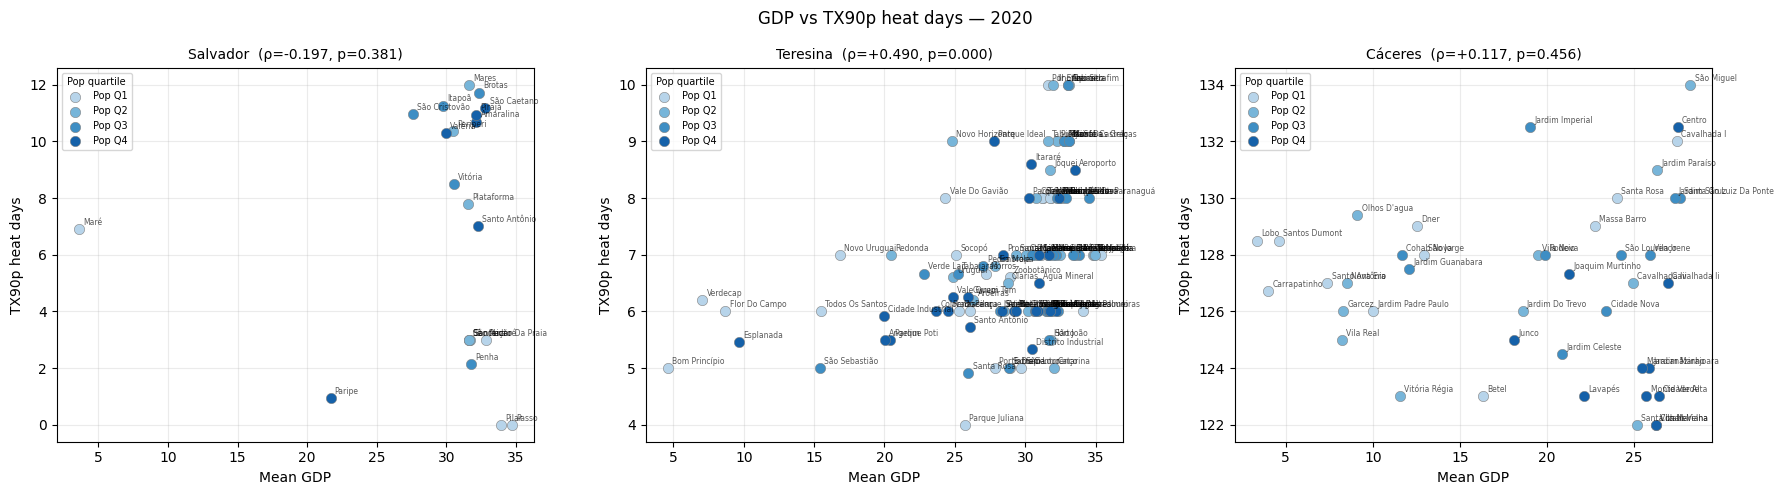

In [23]:
pairs = [
    ('mean_gdp', 'tx90p_hd',   'GDP vs TX90p heat days'),
    ('mean_gdp', 'abs_hd',     'GDP vs Abs heat days'),
    ('mean_gdp', 'population', 'GDP vs Population'),
    ('mean_gdp', 'tx90p_pd',   'GDP vs TX90p person-days'),
    ('tx90p_hd', 'population', 'TX90p heat days vs Population'),
]

rho_rows = []
for city in CITY_KEYS:
    df = city_df[city]
    for a, b, label in pairs:
        r, p = spearmanr(df[a], df[b])
        rho_rows.append({'City': CITY_LABELS[city], 'Comparison': label,
                         'ρ': r, 'p-value': p})

rho_table = pd.DataFrame(rho_rows)
display(
    rho_table.pivot(index='Comparison', columns='City', values='ρ')
    .style
    .format('{:+.3f}')
    .background_gradient(cmap='RdYlGn', vmin=-1, vmax=1, axis=None)
    .set_caption('Spearman ρ — GDP vs heat/population by city')
    .set_table_styles(table_styles)
)

# Scatter plots for GDP vs TX90p heat days, one panel per city
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'GDP vs TX90p heat days — {DIAG_YEAR}', fontsize=12)

for ax, city in zip(axes, CITY_KEYS):
    df = city_df[city]
    rho, p = spearmanr(df['mean_gdp'], df['tx90p_hd'])
    pop_q  = pd.qcut(df['population'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
    cmap   = plt.cm.Blues
    for i, q in enumerate(['Q1', 'Q2', 'Q3', 'Q4']):
        mask = pop_q == q
        ax.scatter(df.loc[mask, 'mean_gdp'], df.loc[mask, 'tx90p_hd'],
                   s=55, color=cmap(0.3 + i * 0.17), edgecolors='grey',
                   linewidth=0.4, label=f'Pop {q}', zorder=3)
    for _, row in df.iterrows():
        ax.annotate(row['name'], (row['mean_gdp'], row['tx90p_hd']),
                    fontsize=5.5, alpha=0.65, xytext=(3, 3), textcoords='offset points')
    ax.set_xlabel('Mean GDP', fontsize=10)
    ax.set_ylabel('TX90p heat days', fontsize=10)
    ax.set_title(f'{CITY_LABELS[city]}  (ρ={rho:+.3f}, p={p:.3f})', fontsize=10)
    ax.legend(title='Pop quartile', fontsize=7, title_fontsize=7)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## Step 9 — GDP-weighted person-days

Follows the same methodology as notebook 10:

- Higher GDP = higher adaptive capacity = **lower** vulnerability weight.
- Vulnerability = `1 − normalised_gdp`
- Two normalisation methods: **A (min-max)** and **B (rank-percentile)**.

The direction is conceptually the same as income weighting in notebook 10, but GDP
captures area-level economic output rather than household income — results will differ.

In [24]:
def add_gdp_weights(df):
    """Adds GDP vulnerability weights and weighted person-day columns in-place."""
    df = df.copy()
    n  = len(df)

    # Method A: min-max
    g_min, g_max            = df['mean_gdp'].min(), df['mean_gdp'].max()
    df['gdp_norm_minmax']   = (df['mean_gdp'] - g_min) / (g_max - g_min)
    df['vuln_minmax']       = 1 - df['gdp_norm_minmax']
    df['weighted_pd_minmax']= df['tx90p_pd'] * df['vuln_minmax']

    # Method B: rank percentile
    df['gdp_rank_asc']      = df['mean_gdp'].rank(ascending=True, method='average')
    df['vuln_rank']         = (df['gdp_rank_asc'] - 1) / (n - 1)
    df['weighted_pd_rank']  = df['tx90p_pd'] * df['vuln_rank']

    # Ranks
    df['rank_unweighted']        = df['tx90p_pd'].rank(ascending=False, method='min').astype(int)
    df['rank_weighted_minmax']   = df['weighted_pd_minmax'].rank(ascending=False, method='min').astype(int)
    df['rank_weighted_rank']     = df['weighted_pd_rank'].rank(ascending=False, method='min').astype(int)
    df['rank_shift_minmax']      = df['rank_unweighted'] - df['rank_weighted_minmax']
    df['rank_shift_rank']        = df['rank_unweighted'] - df['rank_weighted_rank']
    return df


city_df_w = {city: add_gdp_weights(city_df[city]) for city in CITY_KEYS}

# Display Salvador weighted table
df_s = city_df_w['salvador']
display(
    df_s[['name', 'mean_gdp', 'tx90p_pd', 'vuln_minmax', 'vuln_rank',
          'weighted_pd_minmax', 'weighted_pd_rank',
          'rank_unweighted', 'rank_weighted_minmax', 'rank_weighted_rank']]
    .sort_values('rank_weighted_rank')
    .style
    .format({'mean_gdp': '{:.2f}', 'tx90p_pd': '{:,.0f}',
             'vuln_minmax': '{:.3f}', 'vuln_rank': '{:.3f}',
             'weighted_pd_minmax': '{:,.0f}', 'weighted_pd_rank': '{:,.0f}',
             'rank_unweighted': '{:.0f}', 'rank_weighted_minmax': '{:.0f}',
             'rank_weighted_rank': '{:.0f}'})
    .background_gradient(subset=['vuln_minmax', 'vuln_rank'], cmap='RdYlGn_r', vmin=0, vmax=1)
    .set_caption('Salvador — GDP-weighted person-days  (Method A: min-max, Method B: rank)')
    .set_table_styles(table_styles)
)

,name,mean_gdp,tx90p_pd,vuln_minmax,vuln_rank,weighted_pd_minmax,weighted_pd_rank,rank_unweighted,rank_weighted_minmax,rank_weighted_rank
6,São Caetano,32.82,"4,303,580",0.062,0.857,"267,965","3,688,782",1,5,1
4,Pirajá,32.15,"4,006,178",0.084,0.667,"335,414","2,670,785",2,2,2
0,Amaralina,32.17,"2,845,064",0.083,0.714,"236,055","2,032,188",3,7,3
1,Brotas,32.33,"2,078,214",0.078,0.810,"161,818","1,682,363",4,8,4
5,Santo Antônio,32.28,"1,562,627",0.079,0.762,"124,054","1,190,573",7,10,5
20,Valéria,29.98,"1,814,978",0.153,0.190,"278,358","345,710",6,4,6
21,Vitória,30.55,"1,167,467",0.135,0.286,"157,704","333,562",9,9,7
3,Itapoã,29.80,"1,982,070",0.159,0.143,"315,324","283,153",5,3,8
13,Penha,31.76,"445,397",0.096,0.619,"42,873","275,722",13,13,9
16,Plataforma,31.58,"484,298",0.102,0.333,"49,371","161,433",12,12,10


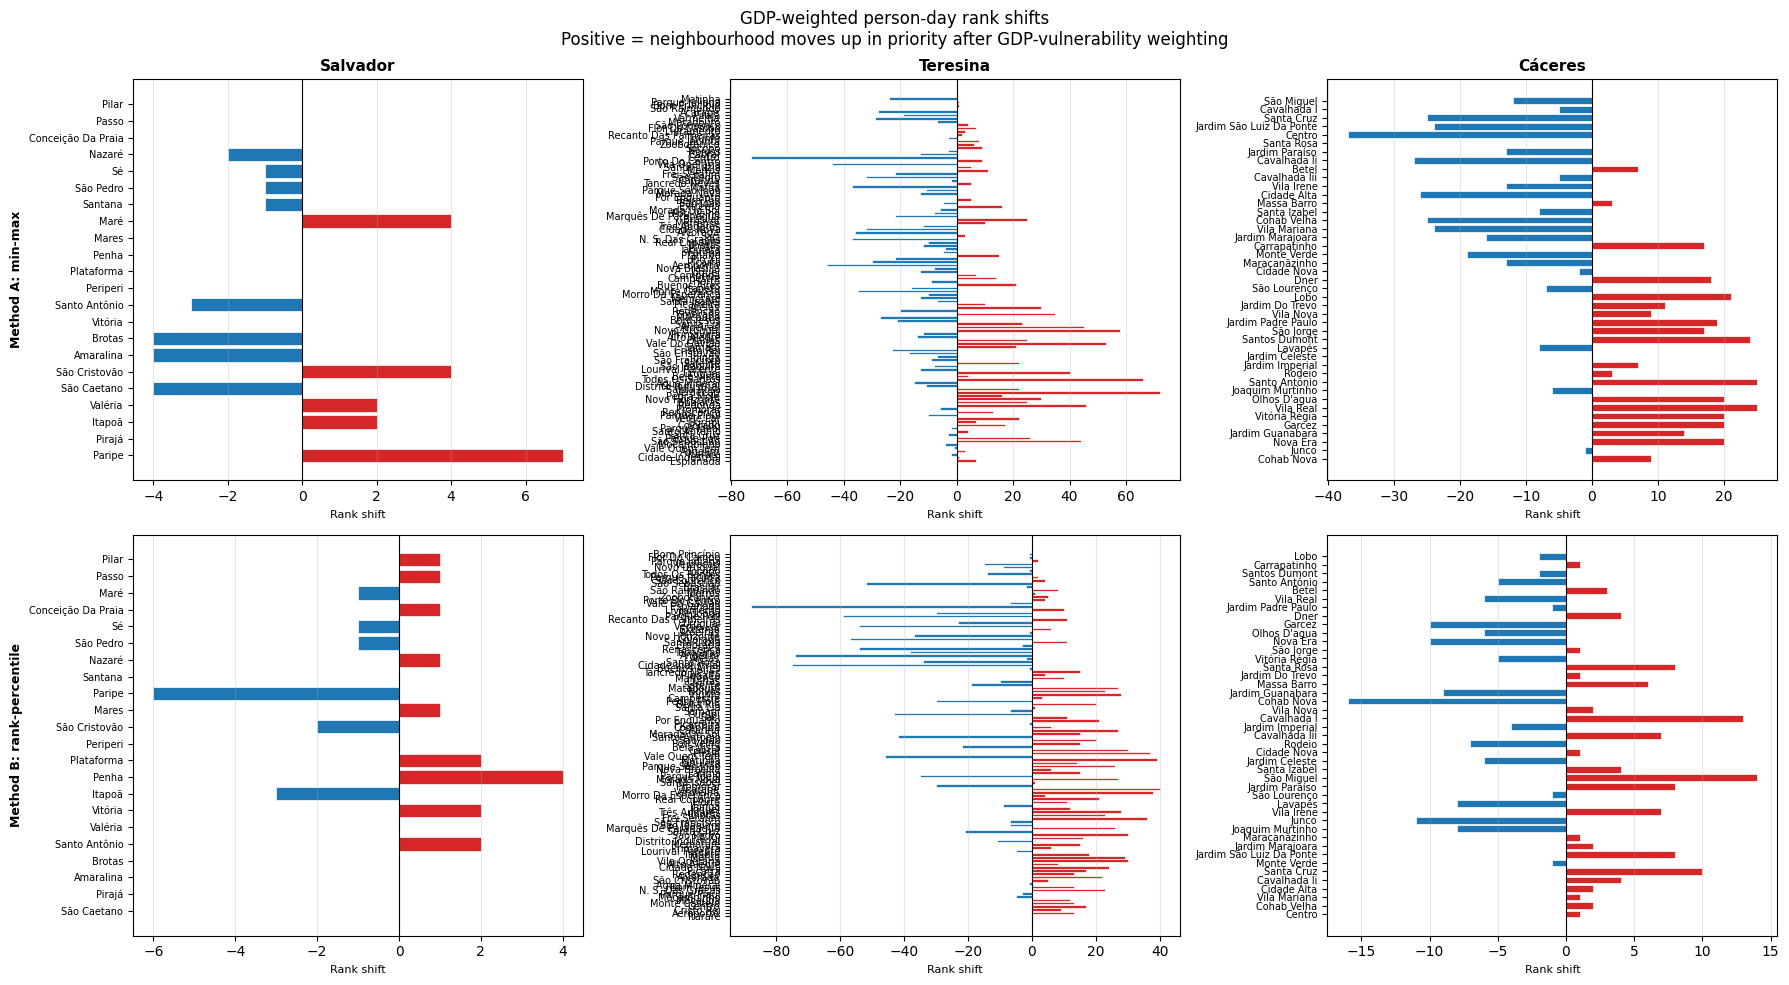

In [25]:
# Rank-shift bar charts for all three cities
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'GDP-weighted person-day rank shifts\n'
    'Positive = neighbourhood moves up in priority after GDP-vulnerability weighting',
    fontsize=12,
)

for col_idx, city in enumerate(CITY_KEYS):
    df = city_df_w[city]
    for row_idx, (method, shift_col, weight_col, title_suffix) in enumerate([
        ('rank_weighted_minmax', 'rank_shift_minmax', 'vuln_minmax', 'Method A: min-max'),
        ('rank_weighted_rank',   'rank_shift_rank',   'vuln_rank',   'Method B: rank-percentile'),
    ]):
        ax       = axes[row_idx, col_idx]
        plot_df  = df.sort_values(method).reset_index(drop=True)
        colors   = ['#d62728' if s > 0 else '#1f77b4' if s < 0 else '#aaaaaa'
                    for s in plot_df[shift_col]]
        ax.barh(plot_df['name'], plot_df[shift_col],
                color=colors, edgecolor='white', linewidth=0.5)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Rank shift', fontsize=8)
        if col_idx == 0:
            ax.set_ylabel(title_suffix, fontsize=9, fontweight='bold')
        if row_idx == 0:
            ax.set_title(CITY_LABELS[city], fontsize=11, fontweight='bold')
        ax.tick_params(axis='y', labelsize=7)
        ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Step 10 — Comparison with Census income ranks (Salvador only)

**This comparison is rank-order only.**  GDP (USD PPP/km²) and household income
(BRL/month) are different quantities — the numbers cannot be directly compared.

What can be compared: **whether richer neighbourhoods by census income are also
higher-GDP neighbourhoods by the global raster.**  A high Spearman ρ would mean
the global GDP raster is a reasonable spatial proxy for census income in Salvador;
a low ρ would suggest the raster misses intra-urban variation.

This cell only runs if the Salvador income GeoJSON from notebook 10 is present.

Salvador GDP vs income rank correlation: ρ = +0.249  (p = 0.2635)
  → Weak agreement: GDP raster does not reflect fine-grained income variation.


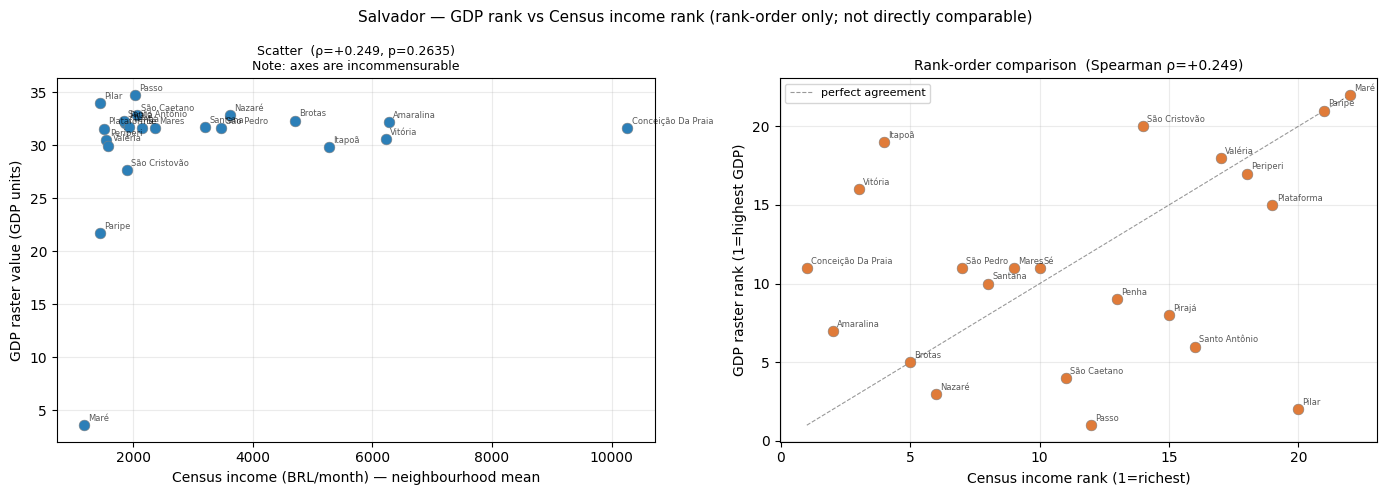

,name,mean_income,mean_gdp,rank_income,rank_gdp,rank_diff
15,Pilar,1452,33.95,20,2,18
3,Itapoã,5277,29.80,4,19,15
21,Vitória,6220,30.55,3,16,13
12,Passo,2026,34.76,12,1,11
2,Conceição Da Praia,10261,31.61,1,11,10
5,Santo Antônio,1847,32.28,16,6,10
4,Pirajá,1865,32.15,15,8,7
6,São Caetano,2059,32.82,11,4,7
7,São Cristovão,1895,27.63,14,20,6
0,Amaralina,6270,32.17,2,7,5


In [26]:
INCOME_FILE = 'data/renda_responsavel_2927408_georedus_censo_2022.geojson'
PROJ_CRS_SAL = CITY_PROJ_CRS['salvador']

if not Path(INCOME_FILE).exists():
    print(f'Income GeoJSON not found: {INCOME_FILE}')
    print('Run notebook 10 first to generate the income data, then re-run this cell.')
    print('\nSkipping GDP vs income comparison.')
else:
    income_raw  = gpd.read_file(INCOME_FILE)
    income_gdf  = income_raw.dropna(subset=['renda_responsavel']).reset_index(drop=True)
    income_gdf  = income_gdf.to_crs(districts['salvador'].crs)

    income_proj  = income_gdf.to_crs(PROJ_CRS_SAL)
    dist_proj    = districts['salvador'].to_crs(PROJ_CRS_SAL)

    income_pts   = income_gdf[['id', 'renda_responsavel']].copy()
    income_pts['geometry'] = income_proj.geometry.centroid
    income_pts   = gpd.GeoDataFrame(income_pts, crs=PROJ_CRS_SAL)

    joined = gpd.sjoin(income_pts, dist_proj[['name', 'geometry']],
                       how='left', predicate='within')
    unmatched = joined['name'].isna()
    if unmatched.sum() > 0:
        nearest = gpd.sjoin_nearest(
            income_pts.loc[unmatched],
            dist_proj[['name', 'geometry']], how='left'
        )[['name']]
        joined.loc[unmatched, 'name'] = nearest['name'].values

    income_by_nbhd = (
        joined.groupby('name')['renda_responsavel']
        .mean().reset_index().rename(columns={'renda_responsavel': 'mean_income'})
    )

    compare = city_df_w['salvador'][['name', 'mean_gdp']].merge(
        income_by_nbhd, on='name', how='inner'
    )
    compare['rank_gdp']    = compare['mean_gdp'].rank(ascending=False, method='min')
    compare['rank_income'] = compare['mean_income'].rank(ascending=False, method='min')
    rho_gi, p_gi = spearmanr(compare['rank_gdp'], compare['rank_income'])

    print(f'Salvador GDP vs income rank correlation: ρ = {rho_gi:+.3f}  (p = {p_gi:.4f})')
    if abs(rho_gi) >= 0.7:
        print('  → Strong agreement: GDP raster reflects census income spatial pattern.')
    elif abs(rho_gi) >= 0.4:
        print('  → Moderate agreement: GDP raster partially captures income inequality.')
    else:
        print('  → Weak agreement: GDP raster does not reflect fine-grained income variation.')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Salvador — GDP rank vs Census income rank (rank-order only; not directly comparable)',
                 fontsize=11)

    ax = axes[0]
    ax.scatter(compare['mean_income'], compare['mean_gdp'], s=60,
               color='#2c7fb8', edgecolors='grey', linewidth=0.4, zorder=3)
    for _, row in compare.iterrows():
        ax.annotate(row['name'], (row['mean_income'], row['mean_gdp']),
                    fontsize=6, alpha=0.65, xytext=(3, 3), textcoords='offset points')
    ax.set_xlabel('Census income (BRL/month) — neighbourhood mean', fontsize=10)
    ax.set_ylabel('GDP raster value (GDP units)', fontsize=10)
    ax.set_title(f'Scatter  (ρ={rho_gi:+.3f}, p={p_gi:.4f})\n'
                 'Note: axes are incommensurable', fontsize=9)
    ax.grid(True, alpha=0.25)

    ax = axes[1]
    ax.scatter(compare['rank_income'], compare['rank_gdp'], s=60,
               color='#e07b39', edgecolors='grey', linewidth=0.4, zorder=3)
    for _, row in compare.iterrows():
        ax.annotate(row['name'], (row['rank_income'], row['rank_gdp']),
                    fontsize=6, alpha=0.65, xytext=(3, 3), textcoords='offset points')
    ax.plot([1, len(compare)], [1, len(compare)], 'k--', lw=0.8, alpha=0.4, label='perfect agreement')
    ax.set_xlabel('Census income rank (1=richest)', fontsize=10)
    ax.set_ylabel('GDP raster rank (1=highest GDP)', fontsize=10)
    ax.set_title(f'Rank-order comparison  (Spearman ρ={rho_gi:+.3f})', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()

    display(
        compare[['name', 'mean_income', 'mean_gdp', 'rank_income', 'rank_gdp']]
        .assign(rank_diff=lambda d: (d['rank_gdp'] - d['rank_income']).abs())
        .sort_values('rank_diff', ascending=False)
        .style
        .format({'mean_income': '{:.0f}', 'mean_gdp': '{:.2f}',
                 'rank_income': '{:.0f}', 'rank_gdp': '{:.0f}', 'rank_diff': '{:.0f}'})
        .background_gradient(subset=['rank_diff'], cmap='YlOrRd')
        .set_caption('Salvador: largest rank disagreements between GDP raster and census income')
        .set_table_styles(table_styles)
    )

## Summary

### What this notebook establishes

1. **Efficient extraction** — city GDP windows are read from a 2.2 GB global raster
   using rasterio windowed reads (the file's internal 128 × 128 tiling makes this fast).
   Extracted city files (~3–8 KB each) are cached in `data/gdp_2019_{city}.tif` for
   re-use in subsequent runs without touching the source raster.

2. **GDP spatial patterns** — choropleth maps show intra-urban GDP variation across
   the neighbourhood boundaries of Salvador (22), Teresina (112), and Cáceres (43).

3. **CV comparison** — the relative spatial inequality in GDP is compared against
   population and heat-day variation within each city.  Cross-city differences in
   CV reflect differences in both urban structure and data resolution.

4. **GDP–heat correlation** — Spearman ρ shows whether wealthier (higher-GDP)
   neighbourhoods are systematically cooler.  A negative ρ supports GDP as a
   vulnerability modifier; near-zero ρ means GDP weighting reshuffles rankings.

5. **GDP-weighted person-days** — two normalisation methods (min-max, rank-percentile)
   produce vulnerability-adjusted priority indices for each city.

6. **GDP vs income comparison (Salvador, conditional)** — rank-order Spearman ρ between
   the global GDP raster and the 2022 census income layer.  High ρ validates GDP as a
   proxy; low ρ means the coarse raster misses intra-urban wealth gradients.

### Known limitations

- **Resolution mismatch:** the GDP raster is 1 km.  Salvador has 22 large neighbourhoods
  (~40–50 pixels each); Teresina has 112 and Cáceres has 43 — many of their smaller
  neighbourhoods contain only 1–3 pixels.  `all_touched=True` ensures full coverage but
  means a small neighbourhood's GDP value may represent a 1 km² pixel that extends well
  beyond its actual boundary.

- **GDP units:** the raster units (likely USD PPP/km²) conflate area and economic
  activity.  Dense lower-income districts may outscore sparse higher-income suburbs
  simply because more total economic activity occurs per km².  Per-capita GDP would be
  a better proxy for household adaptive capacity.

- **Temporal mismatch:** GDP is 2019; heat and population are 2020.

- **Incommensurability:** GDP and census income cannot be directly compared numerically —
  only rank orderings are compared in Step 10.